# B141 Data Mining — Individual Project

## 1. Project Objective and Scope

**Dataset**: UCI Online Retail II  
**Source**: https://archive.ics.uci.edu/dataset/502/online+retail+ii  
**Size**: ~500,000 transactions, 8 features  
**Period**: December 2009 – December 2011  

From the perspective of a newly appointed data scientist at a UK-based online gift retailer,
this project applies a data mining pipeline to the company's transaction
history to extract actionable business insights.

**Research questions:**
1. Which products are most frequently purchased together? (Association Rule Mining)
2. Are there abnormal transactions in the data? (Outlier Detection)
3. Can customers be segmented by behaviour? (RFM Clustering)

The pipeline follows standard data mining practice: preprocessing →
exploratory analysis → technique application → evaluation → recommendations.

In [2]:
# Load dataset, confirm the dataset loads correctly, show 3 rows
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/online_retail_II.xlsx', sheet_name='Year 2010-2011')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (541910, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 3 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [3]:
# Mount Google Drive and install libraries
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported.")

Libraries imported.


#**DATA PREPROCESSING**

Copy of dataset and initial inspection

In [5]:
# A copy of df from the previous cell that now becomes df_raw
# This protects the original so I can always go back to it
df_raw = df.copy()

print(f"Raw shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("\nMissing values:")
print(df_raw.isnull().sum())
print("\nNumeric summary:")
print(df_raw.dtypes)
df_raw[['Quantity', 'Price']].describe().round(2)

Raw shape: 541,910 rows × 8 columns

Missing values:
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

Numeric summary:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


,Quantity,Price
count,541910.00,541910.00
mean,9.55,4.61
std,218.08,96.76
min,-80995.00,-11062.06
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,80995.00,38970.00


Remove missing values

In [6]:
df = df_raw.copy()

# Remove rows with no Customer ID (guest checkouts — can't identify who bought)
df = df.dropna(subset=['Customer ID'])

# Remove rows with no Description (non-product entries like postage)
df = df.dropna(subset=['Description'])

print(f"After removing missing values: {len(df):,} rows")

After removing missing values: 406,830 rows


Remove cancelled orders and invalid records

In [7]:
# Cancelled orders have Invoice starting with 'C' (e.g. C536379)
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove returns (negative quantity) and bad price entries (zero or negative)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print(f"After removing cancellations and invalid records: {len(df):,} rows")

After removing cancellations and invalid records: 397,885 rows


Fix data types

In [8]:
# Customer ID is a float (17850.0) so I convert to string since it's an ID not a number
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)

print(df.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID            object
Country                object
dtype: object


Create new colums (for analysis later)

In [9]:
# Revenue = how much money each line item made
df['Revenue'] = df['Quantity'] * df['Price']

# Month = used later to plot sales trends over time
df['Month'] = df['InvoiceDate'].dt.to_period('M')

print(df[['Quantity', 'Price', 'Revenue', 'Month']].head(5))
print(f"\nTotal revenue in dataset: £{df['Revenue'].sum():,.2f}")

   Quantity  Price  Revenue    Month
0         6   2.55    15.30  2010-12
1         6   3.39    20.34  2010-12
2         8   2.75    22.00  2010-12
3         6   3.39    20.34  2010-12
4         6   3.39    20.34  2010-12

Total revenue in dataset: £8,911,425.90


Final check

In [10]:
print("=" * 45)
print("CLEAN DATASET SUMMARY")
print("=" * 45)
print(f"Rows:              {len(df):,}")
print(f"Missing values:    {df.isnull().sum().sum()}")
print(f"Unique customers:  {df['Customer ID'].nunique():,}")
print(f"Unique products:   {df['StockCode'].nunique():,}")
print(f"Unique invoices:   {df['Invoice'].nunique():,}")
print(f"Countries:         {df['Country'].nunique()}")
print(f"Date range:        {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Total revenue:     £{df['Revenue'].sum():,.2f}")

CLEAN DATASET SUMMARY
Rows:              397,885
Missing values:    0
Unique customers:  4,338
Unique products:   3,665
Unique invoices:   18,532
Countries:         37
Date range:        2010-12-01 → 2011-12-09
Total revenue:     £8,911,425.90


In [11]:
df.to_csv('/content/drive/MyDrive/online_retail_clean.csv', index=False)
print("Saved. In future sections load with:")
print("   df = pd.read_csv('/content/drive/MyDrive/online_retail_clean.csv')")

Saved. In future sections load with:
   df = pd.read_csv('/content/drive/MyDrive/online_retail_clean.csv')


# **EDA**

Load Clean Data

In [12]:
df = pd.read_csv('/content/drive/MyDrive/online_retail_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

print(df.shape)

(397885, 10)


Basic Statistics

In [13]:
df[['Quantity', 'Price', 'Revenue']].describe().round(2)

,Quantity,Price,Revenue
count,397885.00,397885.00,397885.00
mean,12.99,3.12,22.40
std,179.33,22.10,309.07
min,1.00,0.00,0.00
25%,2.00,1.25,4.68
50%,6.00,1.95,11.80
75%,12.00,3.75,19.80
max,80995.00,8142.75,168469.60


Top 10 products by revenue

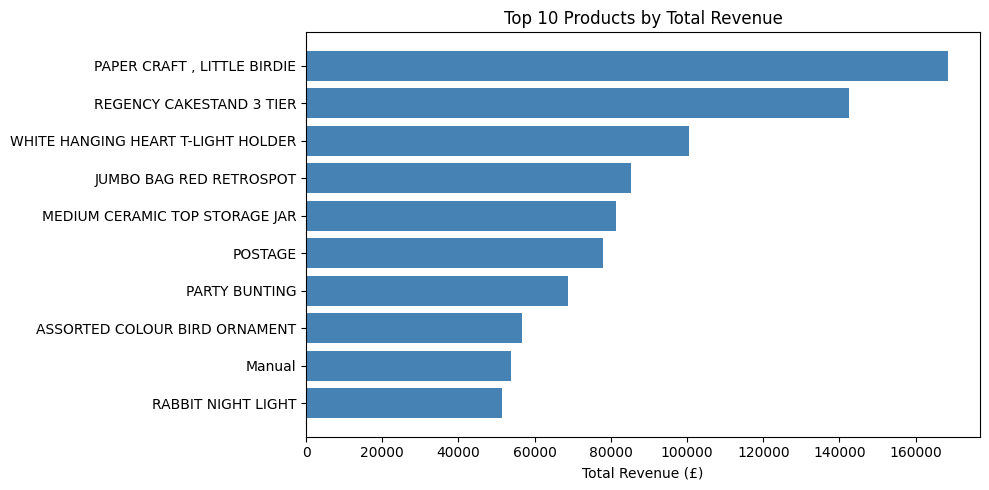

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
Name: Revenue, dtype: float64


In [14]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_products.index, top_products.values, color='steelblue')
plt.xlabel('Total Revenue (£)')
plt.title('Top 10 Products by Total Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('figure1_top_products.png', dpi=150)
plt.show()
print(top_products.head(3))

Revenue by country (excluding UK to show others clearly)

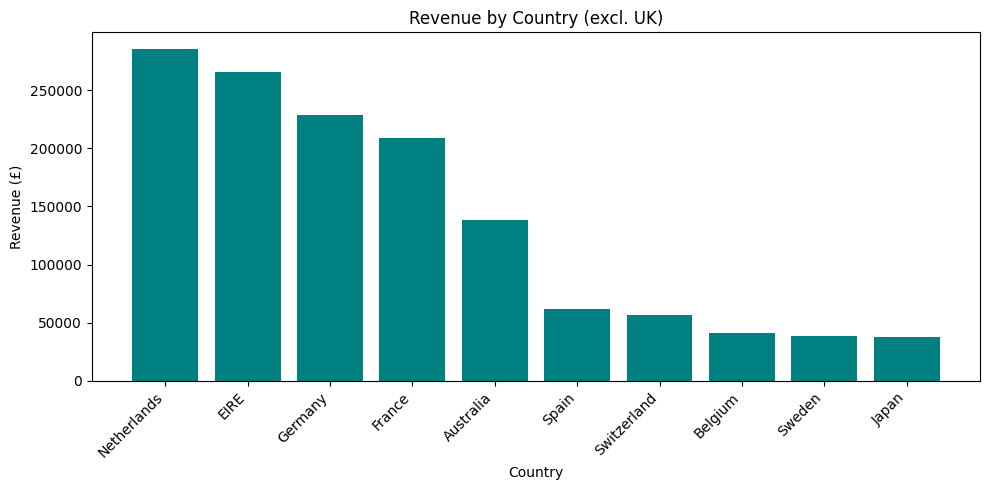

UK share of total revenue: 82.0%


In [15]:
by_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

# Without UK so other countries are visible
no_uk = by_country.drop('United Kingdom').head(10)

plt.figure(figsize=(10, 5))
plt.bar(no_uk.index, no_uk.values, color='teal')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.title('Revenue by Country (excl. UK)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figure2_revenue_by_country.png', dpi=150)
plt.show()

# Print UK's share separately
uk_pct = by_country['United Kingdom'] / by_country.sum() * 100
print(f"UK share of total revenue: {uk_pct:.1f}%")

Monthly revenue trend

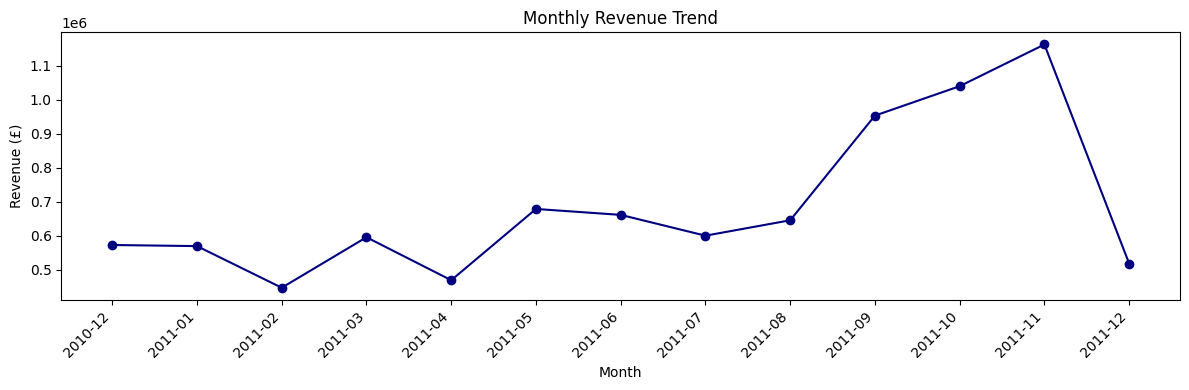

Peak month: 2011-11  —  £1,161,817


In [16]:
monthly = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12, 4))
plt.plot(monthly.index.astype(str), monthly.values, marker='o', color='navy')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figure3_monthly_trend.png', dpi=150)
plt.show()

print(f"Peak month: {monthly.idxmax()}  —  £{monthly.max():,.0f}")

Revenue distribution histogram

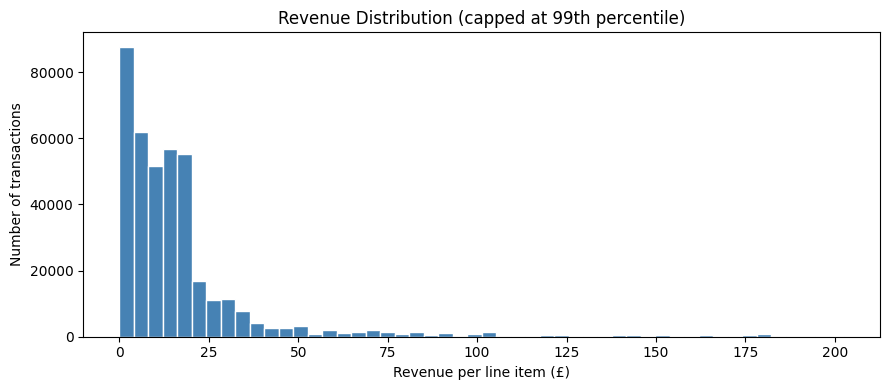

Median: £11.80
Mean:   £22.40


In [17]:
# Cap at 99th percentile so extreme outliers don't squash the chart
cap = df['Revenue'].quantile(0.99)
rev_capped = df[df['Revenue'] <= cap]['Revenue']

plt.figure(figsize=(9, 4))
plt.hist(rev_capped, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Revenue per line item (£)')
plt.ylabel('Number of transactions')
plt.title('Revenue Distribution (capped at 99th percentile)')
plt.tight_layout()
plt.savefig('figure4_revenue_dist.png', dpi=150)
plt.show()

print(f"Median: £{df['Revenue'].median():.2f}")
print(f"Mean:   £{df['Revenue'].mean():.2f}")

Orders by day of week

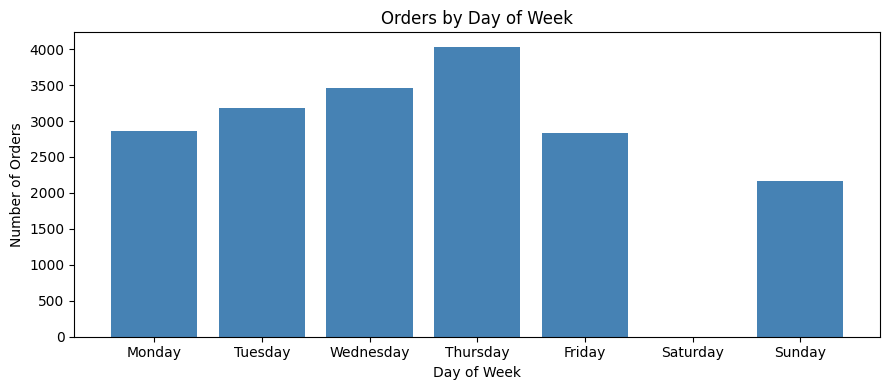

In [18]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df.groupby('DayOfWeek')['Invoice'].nunique().reindex(day_order)

plt.figure(figsize=(9, 4))
plt.bar(day_counts.index, day_counts.values, color='steelblue')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.title('Orders by Day of Week')
plt.tight_layout()
plt.savefig('figure5_day_of_week.png', dpi=150)
plt.show()

Key Numbers

In [19]:
print("=== KEY NUMBERS ===")
print(f"Top product:     {top_products.index[0]}")
print(f"Top revenue:     £{top_products.values[0]:,.0f}")
print(f"UK % of revenue: {uk_pct:.1f}%")
print(f"Peak month:      {monthly.idxmax()}")
print(f"Peak revenue:    £{monthly.max():,.0f}")
print(f"Busiest day:     {day_counts.idxmax()}")
print(f"Revenue median:  £{df['Revenue'].median():.2f}")
print(f"Revenue mean:    £{df['Revenue'].mean():.2f}")

=== KEY NUMBERS ===
Top product:     PAPER CRAFT , LITTLE BIRDIE
Top revenue:     £168,470
UK % of revenue: 82.0%
Peak month:      2011-11
Peak revenue:    £1,161,817
Busiest day:     Thursday
Revenue median:  £11.80
Revenue mean:    £22.40


#**Associatition Rule Mining ( Apriori)**

Build the basket

In [20]:
# UK only to keep it manageable (most transactions are UK)
df_uk = df[df['Country'] == 'United Kingdom']

# Build basket: one row per invoice, one column per product
# 1 = product was in that invoice, 0 = it wasn't
basket = df_uk.groupby(['Invoice', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket = basket.map(lambda x: 1 if x > 0 else 0)

print(f"Basket shape: {basket.shape[0]} invoices x {basket.shape[1]} products")

Basket shape: 16646 invoices x 3844 products


Calculate support for each item

In [21]:
n_transactions = len(basket)

# Support = how often each item appears across all invoices
item_support = basket.sum() / n_transactions

# Keep only items that appear in at least 2% of invoices (min support)
min_support = 0.02
frequent_items = item_support[item_support >= min_support].sort_values(ascending=False)

print(f"Frequent items (support >= {min_support}): {len(frequent_items)}")
print(frequent_items.head(10))

Frequent items (support >= 0.02): 199
Description
WHITE HANGING HEART T-LIGHT HOLDER    0.113180
JUMBO BAG RED RETROSPOT               0.086928
REGENCY CAKESTAND 3 TIER              0.084705
ASSORTED COLOUR BIRD ORNAMENT         0.078097
PARTY BUNTING                         0.077496
LUNCH BAG RED RETROSPOT               0.067283
SET OF 3 CAKE TINS PANTRY DESIGN      0.060495
LUNCH BAG  BLACK SKULL.               0.059834
PAPER CHAIN KIT 50'S CHRISTMAS        0.056770
NATURAL SLATE HEART CHALKBOARD        0.056350
dtype: float64


Generate pairs and calculate confidence & lift

In [22]:
# Compare every pair of frequent items
items = frequent_items.index.tolist()
rules = []

for i in range(len(items)):
    for j in range(i + 1, len(items)):
        item_a = items[i]
        item_b = items[j]

        # Support of the pair (both appear in same invoice)
        support_ab = ((basket[item_a] == 1) & (basket[item_b] == 1)).sum() / n_transactions

        if support_ab >= min_support:
            # Confidence: if A, how often also B?
            confidence_ab = support_ab / (basket[item_a].sum() / n_transactions)

            # Lift: how much more likely than by chance?
            lift = support_ab / ((basket[item_a].sum() / n_transactions) * (basket[item_b].sum() / n_transactions))

            rules.append([item_a, item_b, round(support_ab, 4), round(confidence_ab, 4), round(lift, 4)])

rules_df = pd.DataFrame(rules, columns=['Item_A', 'Item_B', 'Support', 'Confidence', 'Lift'])
rules_df = rules_df.sort_values('Lift', ascending=False).reset_index(drop=True)

print(f"Association rules found: {len(rules_df)}")
rules_df.head(10)

Association rules found: 35


,Item_A,Item_B,Support,Confidence,Lift
0,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.0243,0.6601,22.2891
1,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0286,0.7021,19.0957
2,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.0230,0.5649,19.0736
3,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.0275,0.6173,16.3872
4,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.0273,0.5989,14.4493
5,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.0275,0.5363,11.3868
6,PAPER CHAIN KIT 50'S CHRISTMAS,PAPER CHAIN KIT VINTAGE CHRISTMAS,0.0263,0.4624,11.3703
7,LUNCH BAG SPACEBOY DESIGN,LUNCH BAG WOODLAND,0.0208,0.3963,9.7884
8,HEART OF WICKER SMALL,HEART OF WICKER LARGE,0.0239,0.4289,9.0254
9,LUNCH BAG CARS BLUE,LUNCH BAG PINK POLKADOT,0.0238,0.4490,8.8133


Show top rules clearly

In [23]:
print("=== TOP 10 ASSOCIATION RULES BY LIFT ===\n")
for _, row in rules_df.head(10).iterrows():
    print(f"IF '{row['Item_A']}'")
    print(f"THEN '{row['Item_B']}'")
    print(f"  Support: {row['Support']}  |  Confidence: {row['Confidence']}  |  Lift: {row['Lift']}")
    print()

=== TOP 10 ASSOCIATION RULES BY LIFT ===

IF 'GREEN REGENCY TEACUP AND SAUCER'
THEN 'PINK REGENCY TEACUP AND SAUCER'
  Support: 0.0243  |  Confidence: 0.6601  |  Lift: 22.2891

IF 'ROSES REGENCY TEACUP AND SAUCER '
THEN 'GREEN REGENCY TEACUP AND SAUCER'
  Support: 0.0286  |  Confidence: 0.7021  |  Lift: 19.0957

IF 'ROSES REGENCY TEACUP AND SAUCER '
THEN 'PINK REGENCY TEACUP AND SAUCER'
  Support: 0.023  |  Confidence: 0.5649  |  Lift: 19.0736

IF 'GARDENERS KNEELING PAD KEEP CALM '
THEN 'GARDENERS KNEELING PAD CUP OF TEA '
  Support: 0.0275  |  Confidence: 0.6173  |  Lift: 16.3872

IF 'ALARM CLOCK BAKELIKE RED '
THEN 'ALARM CLOCK BAKELIKE GREEN'
  Support: 0.0273  |  Confidence: 0.5989  |  Lift: 14.4493

IF 'WOODEN PICTURE FRAME WHITE FINISH'
THEN 'WOODEN FRAME ANTIQUE WHITE '
  Support: 0.0275  |  Confidence: 0.5363  |  Lift: 11.3868

IF 'PAPER CHAIN KIT 50'S CHRISTMAS '
THEN 'PAPER CHAIN KIT VINTAGE CHRISTMAS'
  Support: 0.0263  |  Confidence: 0.4624  |  Lift: 11.3703

IF 'LUNCH BAG

#**Outlier Detection**

Detect outlier invoices using Z-score

In [24]:
# Total revenue per invoice
invoice_revenue = df.groupby('Invoice')['Revenue'].sum()

# Z-score: how many standard deviations from the mean?
z_scores = np.abs(stats.zscore(invoice_revenue))

# Anything beyond 3 standard deviations is an outlier
outliers = invoice_revenue[z_scores > 3].sort_values(ascending=False)

print(f"Total invoices:    {len(invoice_revenue):,}")
print(f"Outlier invoices:  {len(outliers):,}")
print(f"Outlier threshold: £{invoice_revenue.mean() + 3*invoice_revenue.std():,.2f}")
print()
print("Top 10 highest outlier invoices:")
print(outliers.head(10))
# What percentage of revenue are outliers (outliers transaction represent a disproportionate share of revenue)
outlier_revenue = invoice_revenue[np.abs(stats.zscore(invoice_revenue)) > 3].sum()
total_revenue = invoice_revenue.sum()
print(f"Outlier % of invoices: {99/18532*100:.2f}%")
print(f"Outlier % of revenue:  {outlier_revenue/total_revenue*100:.1f}%")

Total invoices:    18,532
Outlier invoices:  99
Outlier threshold: £5,515.45

Top 10 highest outlier invoices:
Invoice
581483    168469.60
541431     77183.60
556444     38970.00
567423     31698.16
556917     22775.93
572209     22206.00
567381     22104.80
563614     21880.44
550461     21535.90
572035     20277.92
Name: Revenue, dtype: float64
Outlier % of invoices: 0.53%
Outlier % of revenue:  14.5%


Visualise Outliers

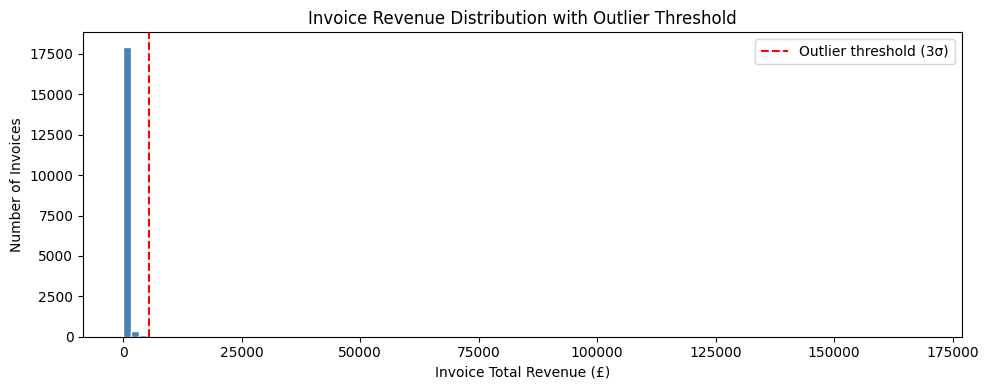

Mean invoice value:   £480.87
Median invoice value: £303.04
Max invoice value:    £168,469.60


In [25]:
plt.figure(figsize=(10, 4))
plt.hist(invoice_revenue, bins=100, color='steelblue', edgecolor='white')
plt.axvline(invoice_revenue.mean() + 3*invoice_revenue.std(), color='red', linestyle='--', label='Outlier threshold (3σ)')
plt.xlabel('Invoice Total Revenue (£)')
plt.ylabel('Number of Invoices')
plt.title('Invoice Revenue Distribution with Outlier Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('fig6_outliers.png', dpi=150)
plt.show()

print(f"Mean invoice value:   £{invoice_revenue.mean():,.2f}")
print(f"Median invoice value: £{invoice_revenue.median():,.2f}")
print(f"Max invoice value:    £{invoice_revenue.max():,.2f}")

#**Customer Segmentation (RFM + KMeans)**

Build RFM Table

In [26]:
# Recency = days since last purchase
# Frequency = number of invoices
# Monetary = total spend

snapshot_date = df['InvoiceDate'].max() + pd.DateOffset(1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(rfm.describe().round(2))

       Customer ID  Recency  Frequency   Monetary
count      4338.00  4338.00    4338.00    4338.00
mean      15300.41    92.54       4.27    2054.27
std        1721.81   100.01       7.70    8989.23
min       12346.00     1.00       1.00       3.75
25%       13813.25    18.00       1.00     307.41
50%       15299.50    51.00       2.00     674.48
75%       16778.75   142.00       5.00    1661.74
max       18287.00   374.00     209.00  280206.02


Normalise and run KMeans

In [27]:
# Normalise so no single feature dominates by scale
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Run KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Show average RFM values per cluster
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1))

         Recency  Frequency  Monetary
Cluster                              
0           43.7        3.7    1359.1
1          248.1        1.6     480.6
2            7.4       82.5  127338.3
3           15.5       22.3   12709.1


Evaluate with silhouette score

In [28]:
score = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f"Silhouette Score: {score:.3f}")

#Interpretation:
#  > 0.5  = strong clusters
#  0.2–0.5 = acceptable clusters
#  < 0.2  = weak clusters

Silhouette Score: 0.616


 Visualise clusters

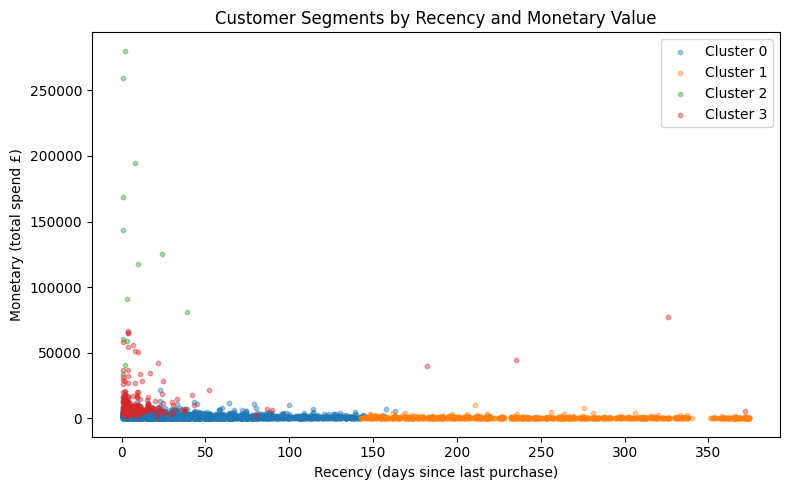

In [29]:
plt.figure(figsize=(8, 5))

for cluster in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Monetary'],
                label=f'Cluster {cluster}', alpha=0.4, s=10)

plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (total spend £)')
plt.title('Customer Segments by Recency and Monetary Value')
plt.legend()
plt.tight_layout()
plt.savefig('fig7_clusters.png', dpi=150)
plt.show()

Label clusters in plain English

In [30]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_summary['Size'] = rfm.groupby('Cluster')['Customer ID'].count()
print(cluster_summary.sort_values('Monetary', ascending=False))

#Averages to label each cluster:
#Low Recency + High Frequency + High Monetary = Champions
#High Recency + Low Frequency + Low Monetary = Lost customers
#Low Recency + Low Frequency + High Monetary = Big spenders / whales
#Mid values across all three = Potential loyalists

         Recency  Frequency  Monetary  Size
Cluster                                    
2            7.4       82.5  127338.3    13
3           15.5       22.3   12709.1   204
0           43.7        3.7    1359.1  3054
1          248.1        1.6     480.6  1067
